In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, classification_report,confusion_matrix, roc_curve, auc

In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
if 'Unnamed: 32' in df.columns: # these are unnecessary columns
  df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
  df = df.drop('id', axis=1)

In [6]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
df.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [8]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [9]:
y.value_counts()

,count
diagnosis,
B,357
M,212


In [10]:
le = LabelEncoder() # we need to encode the diagnosis values , M=0,B=1
y = le.fit_transform(y)

In [11]:
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# we will be using the svc as it will be the most suitable here given that we have 30 features
svc_params = {
'C': [0.1, 1, 10, 100],
'kernel': ['linear', 'rbf'],
'gamma': ['scale', 'auto', 0.1, 0.01]
}

In [14]:
svc_grid = GridSearchCV(
SVC(probability=True, random_state=42),
svc_params,
cv=5,
n_jobs=-1,
scoring='accuracy'
)

In [15]:
svc_grid.fit(X_train_scaled, y_train) # finding the best parameters

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 0.01],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [16]:
best_svc = svc_grid.best_estimator_

In [18]:
print(f"Best Parameters : {svc_grid.best_params_}")

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [20]:
y_pred = best_svc.predict(X_test_scaled) # using this to predict the test dataset

In [21]:
y_pred_proba = best_svc.predict_proba(X_test_scaled)[:, 1]

In [22]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [23]:
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")

Accuracy: 98.25%
Recall: 95.35%


In [24]:
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

               precision    recall  f1-score   support

   Benign (0)       0.97      1.00      0.99        71
Malignant (1)       1.00      0.95      0.98        43

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



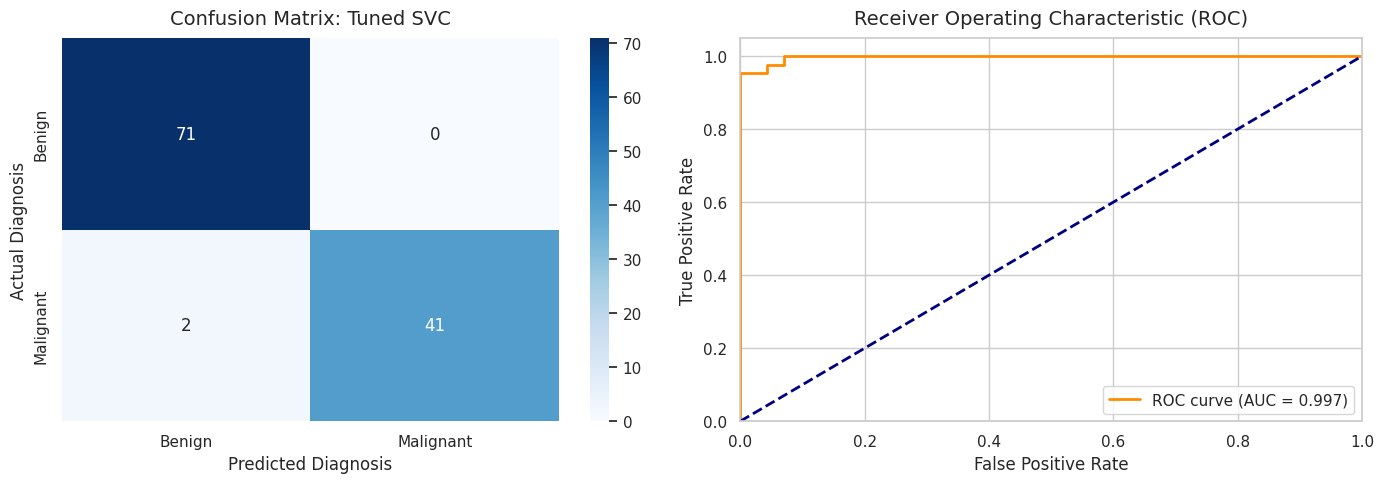

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
xticklabels=['Benign', 'Malignant'],
yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix: Tuned SVC', fontsize=14, pad=10)
axes[0].set_ylabel('Actual Diagnosis')
axes[0].set_xlabel('Predicted Diagnosis')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=10)
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

# Key Takeaways:
1. The absolute best part of this model is that it doesn't cause unnecessary fear. Every single time it flagged a tumor as dangerous, it was dead right.(given the precision of 1 and recall of 1 for diagnosis M and B respectively)
2. When we look at the raw numbers, there is a sobering reality: there were two people in this specific test group who actually had malignant cancer, but the model predicted that their tumors were benign. This is the reason for bengin precision to be .97
3. in a clinical setting, sending 2 patients home with undetected cancer (False Negatives) is highly undesirable(look at the matrix above, even if it means sacrificing some of that perfect 100% precision to catch them


Classification Report (Threshold = 0.05):
               precision    recall  f1-score   support

   Benign (0)       1.00      0.87      0.93        71
Malignant (1)       0.83      1.00      0.91        43

     accuracy                           0.92       114
    macro avg       0.91      0.94      0.92       114
 weighted avg       0.93      0.92      0.92       114



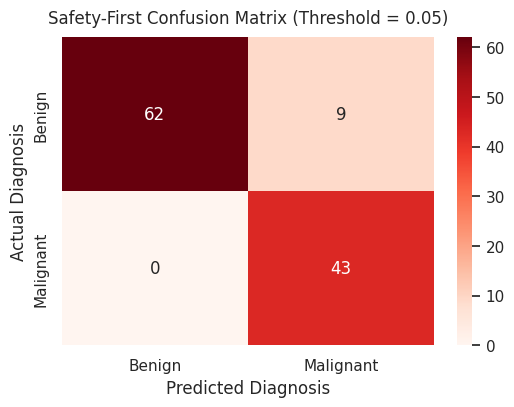

In [30]:
# adjusting to correct recall for m also
y_pred_proba = best_svc.predict_proba(X_test_scaled)[:, 1]

custom_threshold = 0.05 # sensitivy is increased

y_pred_adjusted = (y_pred_proba >= custom_threshold).astype(int)

print(f"\nClassification Report (Threshold = {custom_threshold}):")
print(classification_report(y_test, y_pred_adjusted, target_names=['Benign (0)', 'Malignant (1)']))

cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Safety-First Confusion Matrix (Threshold = {custom_threshold})', fontsize=12, pad=10)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

#### now the false positives are 0 which we wanted as we dont want to miss any actual cases. THough the false alarm rate has been raised from the previous model but looking it from the medical point view we dont want to miss actual cancer patients